# Model Metrics Visualization

Visualizes `metrics.csv`. Produces **one figure per location-encoding variant**
[`cat` (ordinal codes, no coords), `tgt` (target-encoded city/zipcode + cartesian coords)].

Each figure lays out the metrics (`RMSE`, `MAE`, `MAPE`, `R2`, `Adjusted_R2`) across columns. Within
every subplot the models are grouped on the x-axis with separate bars for the train and test split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("metrics.csv")
df.head()

,timestamp,model,target,variant,split,metric,value
0,2026-06-06T14:16:29,mlp,price,cat,train,RMSE,204418.305966
1,2026-06-06T14:16:29,mlp,price,cat,train,MAE,139318.079466
2,2026-06-06T14:16:29,mlp,price,cat,train,MAPE,32.896098
3,2026-06-06T14:16:29,mlp,price,cat,train,R2,0.660946
4,2026-06-06T14:16:29,mlp,price,cat,train,Adjusted_R2,0.659487


In [2]:
# Fixed model order for the x-axis (mlp before mgbdt).
models = ["mlp", "dt", "rf", "mgbdt"]
target = "price"
variants = ["cat", "tgt"]
metrics = ["RMSE", "MAE", "MAPE", "R2", "Adjusted_R2"]
splits = ["train", "test"]

variant_labels = {
    "cat": "categorical encoding (codes, no coords)",
    "tgt": "target + coordinate encoding",
}
split_colors = {"train": "#4C72B0", "test": "#DD8452"}
print("models:", models, "| variants:", variants)

models: ['mlp', 'dt', 'rf', 'mgbdt'] | variants: ['cat', 'tgt']


In [3]:
def plot_variant(variant):
    """One figure of grouped bars for a single location-encoding variant."""
    sub = df[(df["variant"] == variant) & (df["target"] == target)]

    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(4 * len(metrics), 4),
        squeeze=False,
    )

    x = np.arange(len(models))
    width = 0.38

    for c, metric in enumerate(metrics):
        ax = axes[0][c]
        for i, split in enumerate(splits):
            vals = []
            for model in models:
                row = sub[
                    (sub["metric"] == metric)
                    & (sub["split"] == split)
                    & (sub["model"] == model)
                ]["value"]
                vals.append(row.iloc[0] if len(row) else np.nan)
            offset = (i - 0.5) * width
            bars = ax.bar(
                x + offset,
                vals,
                width,
                label=split,
                color=split_colors[split],
            )
            # ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

        ax.set_xticks(x)
        ax.set_xticklabels(models)
        ax.set_title(metric)
        ax.grid(axis="y", alpha=0.3)

    # Single shared legend for the whole figure.
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", ncol=len(splits))
    fig.suptitle(
        f"{target}  |  {variant_labels.get(variant, variant)}",
        fontsize=14,
        fontweight="bold",
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    return fig

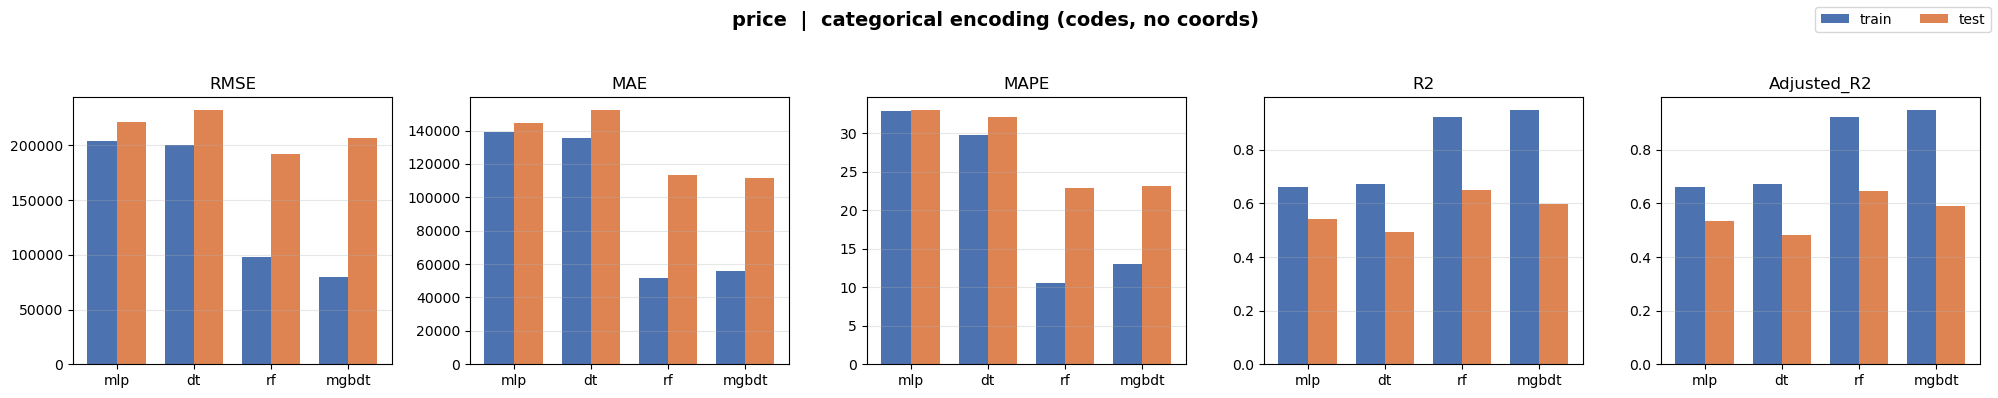

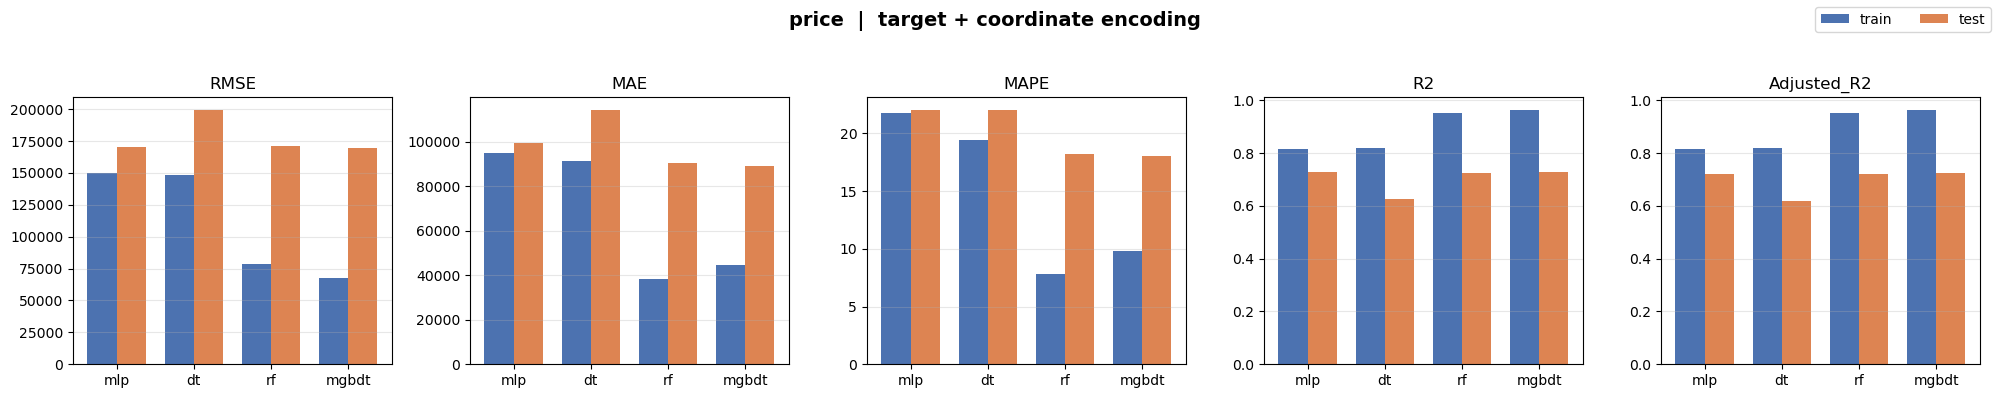

In [4]:
for variant in variants:
    fig = plot_variant(variant)
    fig.savefig(
        f"metrics_{target}_{variant}.png",
        dpi=120,
        bbox_inches="tight",
    )
    plt.show()

## R2 Comparison Across Variants

Compares the **R2** score across the two location-encoding variants
[`cat`, `tgt`]. The variants sit on the x-axis with separate bars per model × split.

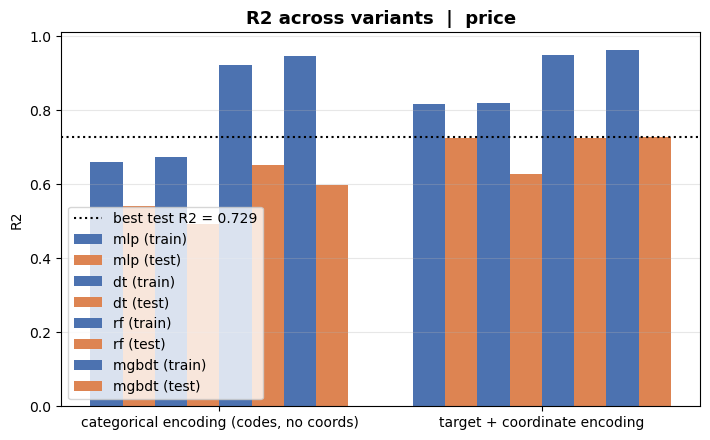

In [5]:
def plot_r2_across_variants():
    """One figure comparing test/train R2 across the encoding variants."""
    fig, ax = plt.subplots(figsize=(2.6 * len(variants) + 2, 4.5))

    x = np.arange(len(variants))
    series = [(model, split) for model in models for split in splits]
    width = 0.8 / len(series)

    for j, (model, split) in enumerate(series):
        vals = []
        for variant in variants:
            row = df[
                (df["variant"] == variant)
                & (df["target"] == target)
                & (df["model"] == model)
                & (df["split"] == split)
                & (df["metric"] == "R2")
            ]["value"]
            vals.append(row.iloc[0] if len(row) else np.nan)
        offset = (j - (len(series) - 1) / 2) * width
        label = f"{model} ({split})" if len(models) > 1 else split
        ax.bar(x + offset, vals, width, label=label, color=split_colors.get(split))

    # Dotted reference line: best test R2 across variants.
    best = df[
        (df["target"] == target) & (df["split"] == "test") & (df["metric"] == "R2")
    ]["value"]
    if len(best):
        best_r2 = best.max()
        ax.axhline(
            best_r2,
            linestyle=":",
            color="black",
            linewidth=1.5,
            label=f"best test R2 = {best_r2:.3f}",
        )

    ax.set_xticks(x)
    ax.set_xticklabels([variant_labels.get(v, v) for v in variants])
    ax.set_ylabel("R2")
    ax.set_title(f"R2 across variants  |  {target}", fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


fig = plot_r2_across_variants()
fig.savefig(f"r2_comparison_{target}.png", dpi=120, bbox_inches="tight")
plt.show()